<a href="https://colab.research.google.com/github/bachecodes/data-science-bootcamp-selection-projects/blob/main/pandas-revision/pandas_revision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 1: Load & Explore Data


*  Load the dataset into a Pandas DataFrame
*  Display the first few rows

*   Check data types and dataset structure
*   Generate summary statistics







In [9]:
import pandas as pd
path= '/content/drive/MyDrive/Sample - Superstore.csv'
# Load dataset
df = pd.read_csv(path, encoding='latin1')

# Preview data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [11]:
df.describe()


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


# Task 2: Data Cleaning
Identify missing values

Handle missing data appropriately

Convert relevant columns to correct data types (e.g., dates)


In [12]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [13]:
# Example: fill missing values
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_2184/1982657770.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

#Task 3: Feature Engineering
Extract Month and Year from the order date

Create a new column based on existing numerical columns

Verify whether your new column is logically correct


In [15]:
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year

In [16]:
df['Profit Ratio'] = df['Profit'] / df['Sales']

In [17]:
df[['Sales', 'Profit', 'Profit Ratio']].head()

,Sales,Profit,Profit Ratio
0,261.9600,41.9136,0.1600
1,731.9400,219.5820,0.3000
2,14.6200,6.8714,0.4700
3,957.5775,-383.0310,-0.4000
4,22.3680,2.5164,0.1125


# Task 4: GroupBy & Aggregation
Calculate total sales by category

Calculate total profit by region

Identify top 5 customers based on sales

Analyze sales trends over time (monthly)


In [18]:
sales_by_category = df.groupby('Category')['Sales'].sum()
print(sales_by_category)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


In [19]:
profit_by_region = df.groupby('Region')['Profit'].sum()
print(profit_by_region)

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64


In [20]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)
print(top_customers)

Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64


In [21]:
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum()
print(monthly_sales)

Order Year  Order Month
2014        1               14236.8950
            2                4519.8920
            3               55691.0090
            4               28295.3450
            5               23648.2870
            6               34595.1276
            7               33946.3930
            8               27909.4685
            9               81777.3508
            10              31453.3930
            11              78628.7167
            12              69545.6205
2015        1               18174.0756
            2               11951.4110
            3               38726.2520
            4               34195.2085
            5               30131.6865
            6               24797.2920
            7               28765.3250
            8               36898.3322
            9               64595.9180
            10              31404.9235
            11              75972.5635
            12              74919.5212
2016        1               18542.4910
 

# Task 5: Pivot Tables
Create pivot tables to show:

Sales by category and region

Sales trends by segment over time
Profit by sub-category

In [23]:
pivot2 = pd.pivot_table(df, values='Sales', index='Order Month', columns='Segment', aggfunc='sum')
pivot2

Segment,Consumer,Corporate,Home Office
Order Month,,,
1,50441.2906,26790.3480,17693.1970
2,33826.1760,14575.0670,11350.0084
3,89174.7070,58239.9132,57590.8686
4,54845.1895,49233.1636,33683.7755
5,86932.7144,47289.0323,20807.0650
6,82910.1803,40858.5370,28949.9620
7,81769.7730,46919.2060,18549.1180
8,82319.8063,57529.4477,19194.8090
9,185055.9196,74020.2213,48573.8048


In [24]:
pivot3 = pd.pivot_table(df, values='Profit', index='Sub-Category', aggfunc='sum')
pivot3

,Profit
Sub-Category,
Accessories,41936.6357
Appliances,18138.0054
Art,6527.7870
Binders,30221.7633
Bookcases,-3472.5560
Chairs,26590.1663
Copiers,55617.8249
Envelopes,6964.1767
Fasteners,949.5182


# Task 6: Data Splitting & Merging
Split the dataset into at least two meaningful DataFrames

Merge them back into a single dataset

Ensure the merged result is correct


In [25]:
df_customers = df[['Customer ID', 'Customer Name', 'Segment']]
df_orders = df[['Order ID', 'Sales', 'Profit']]

In [26]:
merged_df = pd.concat([df_customers, df_orders], axis=1)
merged_df.head()

,Customer ID,Customer Name,Segment,Order ID,Sales,Profit
0,CG-12520,Claire Gute,Consumer,CA-2016-152156,261.9600,41.9136
1,CG-12520,Claire Gute,Consumer,CA-2016-152156,731.9400,219.5820
2,DV-13045,Darrin Van Huff,Corporate,CA-2016-138688,14.6200,6.8714
3,SO-20335,Sean O'Donnell,Consumer,US-2015-108966,957.5775,-383.0310
4,SO-20335,Sean O'Donnell,Consumer,US-2015-108966,22.3680,2.5164


In [27]:
merged_df = pd.merge(df, df_customers, on='Customer ID', how='inner')

# Task 7: Data Visualization
Create the following visualizations using Pandas:

Line chart for sales trend over time

Bar chart for sales by category

Bar chart for profit by region

Pie chart for segment distribution


In [28]:
import matplotlib.pyplot as plt

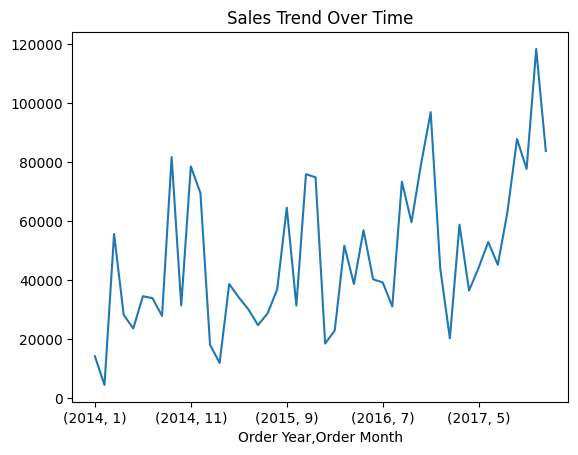

In [29]:
monthly_sales.plot(kind='line')
plt.title("Sales Trend Over Time")
plt.show()

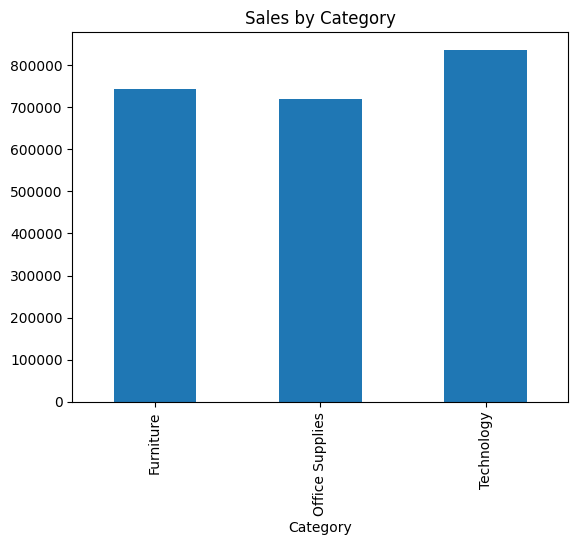

In [30]:
sales_by_category.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

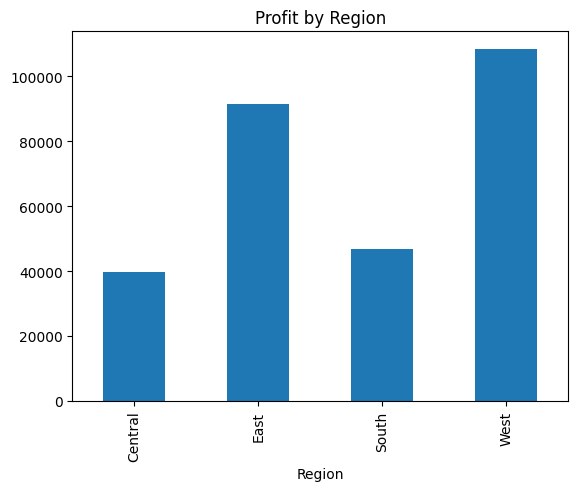

In [31]:
profit_by_region.plot(kind='bar')
plt.title("Profit by Region")
plt.show()

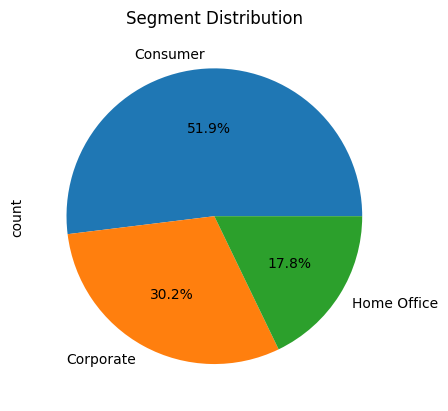

In [32]:
df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Segment Distribution")
plt.show()

# task 8

# Task 8: Final Insights and Analysis

## 1. Most Profitable Category

The Technology category generates the highest total profit.

Reason:

* Products such as phones, accessories, and copiers typically have higher profit margins.
* Customers are willing to spend more on technology products, leading to stronger profitability.



## 2. Least Performing Region

The Central region shows the lowest overall performance in terms of profit.

Possible reasons:

* Higher discounts reducing overall profit
* Lower sales volume compared to other regions
* Inefficient pricing or cost management strategies



## 3. Patterns Between Sales and Profit

An important observation is that sales do not always translate into profit.

Key points:

* High sales do not necessarily result in high profit
* Some transactions with high sales show low or negative profit
* This is often caused by:

  * Heavy discounts
  * High operational or shipping costs

Conclusion:
Profitability depends more on pricing and cost control than on sales volume alone.



## 4. Important Trends Over Time

Based on the sales trend analysis:

Observations:

* There is a general upward trend in sales over time, indicating business growth
* Sales exhibit periodic fluctuations, suggesting seasonal patterns
* Noticeable peaks occur in later years (2016–2017), indicating increased performance
* Occasional sharp declines may reflect low-demand periods or operational challenges



## Final Conclusion

* The business shows consistent growth over time
* Technology is the most profitable category and should be prioritized
* The Central region requires strategic improvement
* Increasing sales alone is not sufficient; focus should be placed on improving profit margins



## Additional Insight

Sub-categories with high sales but low profit should be carefully reviewed to reduce excessive discounting and improve overall profitability.
